<a href="https://colab.research.google.com/github/nonkronk/maim654-project/blob/feature%2Fimprove-recall/electricity-theft-detection/colab/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Electricity Theft Detection

**Track:** Energy Systems — Predictive Maintenance / Anomaly Detection
**Advanced Topics:** XAI (SHAP) + Adversarial Robustness (FGSM)
**Dataset:** UCI Electricity Load Diagrams + Synthetic Theft Labels

### Environment Setup & Dependencies
Configures multi-threading to optimize CPU operations and dynamically verifies or installs required Python packages.

In [ ]:
import os, random, subprocess, sys, importlib.util

SEED, THREADS = 42, '32'
WINDOW_SIZE, WINDOW_STRIDE, TRAIN_RATIO, VAL_RATIO, TEST_RATIO, ANOMALY_RATE = 24, 4, 0.7, 0.1, 0.2, 0.1
MAX_METER_SERIES, MAX_WINDOWS_PER_SERIES = 20, 6000

# Configure threading environment variables
for v in ['OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'NUMEXPR_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS', 'BLIS_NUM_THREADS']:
    os.environ[v] = THREADS
os.environ.update({'OMP_DYNAMIC': 'FALSE', 'MKL_DYNAMIC': 'FALSE', 'KMP_AFFINITY': 'granularity=fine,compact,1,0', 'PYTHONHASHSEED': str(SEED)})

# Check and install missing packages
pkgs = {'sklearn': 'scikit-learn', 'torch': 'torch', 'shap': 'shap', 'lime': 'lime', 'kagglehub': 'kagglehub'}
missing = [p for m, p in pkgs.items() if not importlib.util.find_spec(m)]
if missing: subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + missing)

All required packages already available in this kernel.
Thread env configured to 32 for OpenMP/BLAS backends.
Dependency check complete.


### PyTorch Configuration
Initializes the device (CPU/GPU), sets seeds for reproducibility across libraries, and enables Automatic Mixed Precision (AMP) to accelerate training.

In [ ]:
import warnings, torch, shap, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn import metrics

warnings.filterwarnings('ignore')
np.random.seed(SEED); random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

USE_GPU = torch.cuda.is_available()
device = torch.device('cuda' if USE_GPU else 'cpu')
USE_AMP = PIN_MEMORY = USE_GPU

if USE_GPU:
    torch.backends.cudnn.benchmark = True
    BATCH_SIZE, EVAL_BATCH_SIZE, NUM_WORKERS = 512, 1024, min(8, os.cpu_count() or 1)
else:
    torch.backends.mkldnn.enabled = True
    BATCH_SIZE, EVAL_BATCH_SIZE, NUM_WORKERS = 512, 1024, 0

print(f'PyTorch: {torch.__version__} | Device: {device} | AMP: {USE_AMP}')

PyTorch: 2.11.0+cu130
SHAP: 0.51.0
Device: cuda
GPU: NVIDIA GeForce RTX 3090
GPU memory: 23.56 GB
CPU threads configured: 32/32
torch.get_num_threads(): 32
torch.get_num_interop_threads(): 32
Batch sizes -> train: 512, eval: 1024
DataLoader workers: 8
Automatic mixed precision: True
Torch parallel info:
ATen/Parallel:
	at::get_num_threads() : 32
	at::get_num_interop_threads() : 32
OpenMP 201511 (a.k.a. OpenMP 4.5)
	omp_get_max_threads() : 32
Intel(R) oneAPI Math Kernel Library Version 2024.2-Product Build 20240605 for Intel(R) 64 architecture applications
	mkl_get_max_threads() : 32
Intel(R) MKL-DNN v3.10.2 (Git Hash f1d471933dc852f956fd05389f9313c7148783d5)
std::thread::hardware_concurrency() : 32
Environment variables:
	OMP_NUM_THREADS : 32
	MKL_NUM_THREADS : 32
ATen parallel backend: OpenMP



## Data Acquisition and Exploratory Analysis

This section downloads the dataset, keeps the highest-variance meter streams, and builds richer sliding windows for training, validation, and testing.

In [ ]:
import glob, os, kagglehub, numpy as np, pandas as pd

def read_tabular_file(path):
    for sep in [None, ';', ',']:
        try: return pd.read_csv(path, sep=sep, engine='python' if sep is None else 'c')
        except: pass
    return pd.DataFrame()

def collect_candidates(df):
    c = []
    for col in df.columns:
        s = pd.to_numeric(df[col].astype(str).str.replace(',', '.', regex=False), errors='coerce')
        if s.notna().sum() > 0 and np.isfinite(std := float(s.std(skipna=True))):
            c.append((col, s.ffill().bfill().astype(np.float32), int(s.notna().sum()), std))
    return c

path = kagglehub.dataset_download('eduardojst10/electricityloaddiagrams20112014')
files = sorted(glob.glob(os.path.join(path, '**', '*.[ct][sx][vt]'), recursive=True))
series_candidates = []

for f in files:
    if 'Meter_' in f or not any('Meter_' in m for m in files):
        cands = collect_candidates(read_tabular_file(f))
        if cands:
            best = max(cands, key=lambda x: (x[3], x[2]))
            series_candidates.append({'name': f"{os.path.basename(f).split('.')[0]}::{best[0]}" if 'Meter_' in f else best[0], 'series': best[1].to_numpy(), 'source': f, 'column': best[0], 'valid': best[2], 'std': best[3]})
        if not any('Meter_' in m for m in files) and cands:
            series_candidates = [{'name': c[0], 'series': c[1].to_numpy(), 'source': f, 'column': c[0], 'valid': c[2], 'std': c[3]} for c in sorted(cands, key=lambda x: (x[3], x[2]), reverse=True)]
            break

selected_candidates = sorted(series_candidates, key=lambda x: (x['std'], x['valid']), reverse=True)[:MAX_METER_SERIES]
df = pd.DataFrame({c['name']: c['series'] for c in selected_candidates})
meter_stats = pd.DataFrame([{'meter_name': c['name'], 'std': c['std']} for c in selected_candidates])
print(f"Selected {len(selected_candidates)} meters. Shape: {df.shape}")

Dataset downloaded to: /home/jovyan/.cache/kagglehub/datasets/eduardojst10/electricityloaddiagrams20112014/versions/1
No per-meter files found; falling back to the widest tabular file.
Using wide file: /home/jovyan/.cache/kagglehub/datasets/eduardojst10/electricityloaddiagrams20112014/versions/1/df_kwh_adjusted.csv
Selected 20 meter streams out of 370 candidates.
Meter frame shape (ragged rows are expected): (140256, 20)
Top selected meter streams by variance:
meter_name                                                                                                             source column  valid         std  length
    MT_362 /home/jovyan/.cache/kagglehub/datasets/eduardojst10/electricityloaddiagrams20112014/versions/1/df_kwh_adjusted.csv MT_362 140256 9681.456909  140256
    MT_196 /home/jovyan/.cache/kagglehub/datasets/eduardojst10/electricityloaddiagrams20112014/versions/1/df_kwh_adjusted.csv MT_196 140256 2657.335284  140256
    MT_279 /home/jovyan/.cache/kagglehub/datasets/eduar

### Baseline Visualization
Plots the raw load patterns of the selected meters with the highest variance to ensure data integrity before preprocessing.

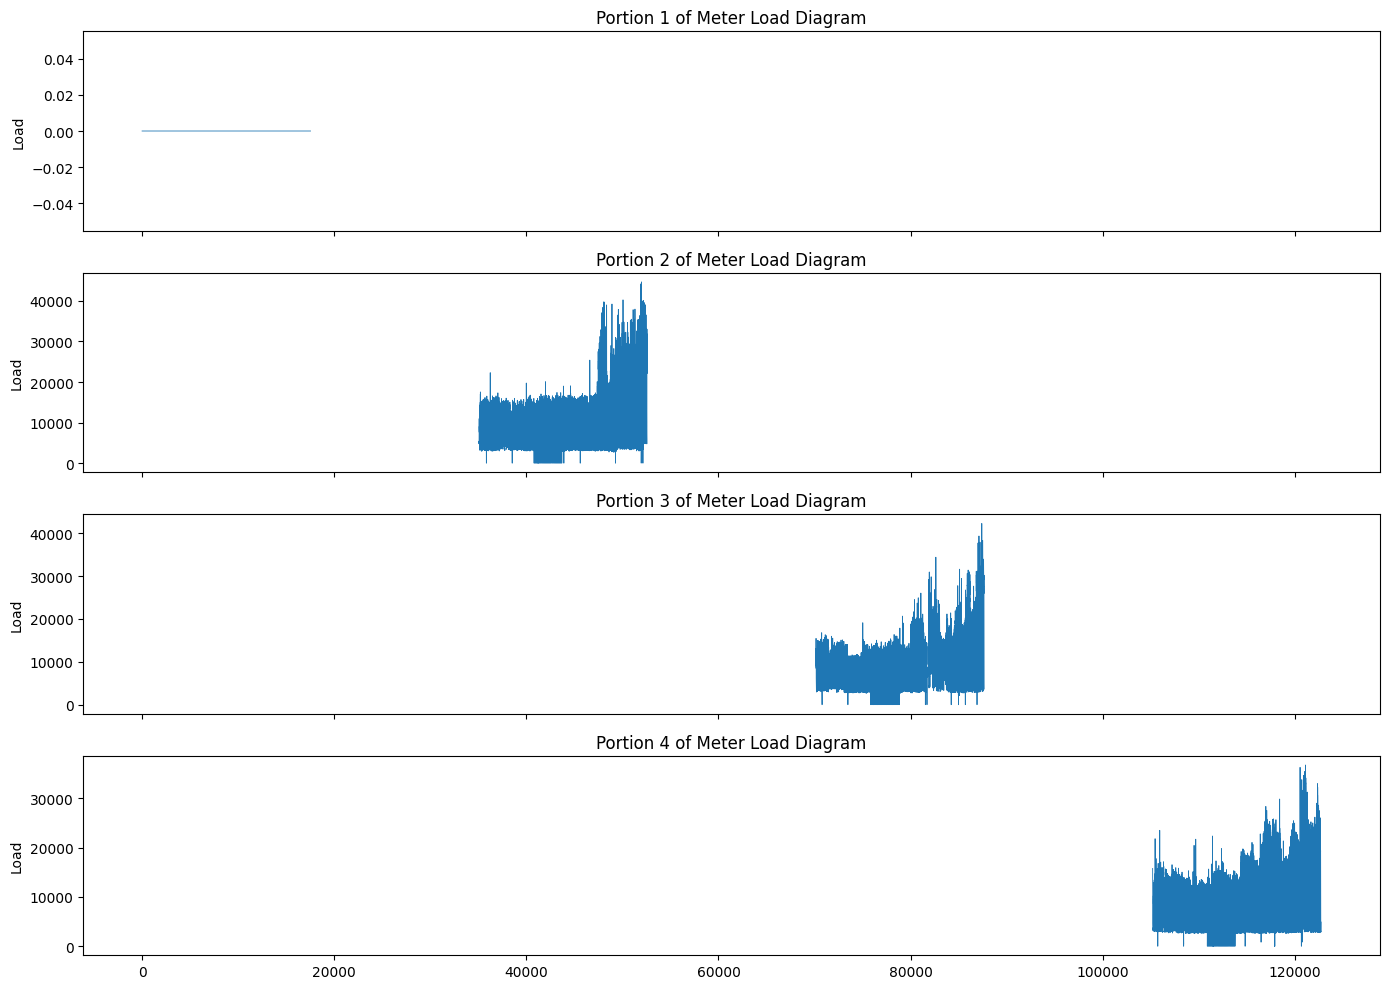

                load
count  140256.000000
mean     9390.235352
std      9681.457031
min         0.000000
25%         0.000000
50%      6025.000000
75%     13700.000000
max     48200.000000
Missing values per column:
Series([], dtype: int64)


In [ ]:
# Plot the highest-variance meter streams for a quick sanity check.
top_plot_cols = meter_stats['meter_name'].head(min(4, len(meter_stats))).tolist()
fig, axes = plt.subplots(len(top_plot_cols), 1, figsize=(14, 3.5 * len(top_plot_cols)), sharex=False)

if len(top_plot_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, top_plot_cols):
    series = df[col].dropna().astype(float).values
    segment_length = min(len(series), WINDOW_SIZE * 14)
    ax.plot(np.arange(segment_length), series[:segment_length], linewidth=0.7)
    ax.set_title(f'High-variance meter stream: {col}')
    ax.set_ylabel('Load')
    ax.grid(alpha=0.2)

axes[-1].set_xlabel('Time index')
plt.tight_layout()
plt.savefig('baseline_load_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

print(df.describe().T[['mean', 'std', 'min', 'max']])

missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print(f'Missing values per column:\n{missing}')
else:
    print('No missing values after loading and alignment.')

### Feature Engineering
Defines functions to convert raw time series into sliding windows and extract rich statistical and cyclical features (e.g., min, max, mean, slope, hour of day).

In [ ]:
def create_time_windows(data, win=WINDOW_SIZE, stride=WINDOW_STRIDE, max_w=MAX_WINDOWS_PER_SERIES):
    data = np.asarray(data, dtype=np.float32)
    starts = np.linspace(0, len(data) - win, min(max_w, len(range(0, len(data) - win + 1, stride))), dtype=np.int64) if len(data) >= win else []
    return (np.stack([data[s:s+win] for s in starts]), starts) if len(starts) else (np.empty((0, win), dtype=np.float32), np.empty((0,), dtype=np.int64))

def build_window_features(wins, win_size=WINDOW_SIZE):
    wins = np.asarray(wins, dtype=np.float32)
    steps = np.arange(win_size, dtype=np.float32)
    h_ang = 2 * np.pi * (steps % 24) / 24
    w_mean, w_std = np.repeat(wins.mean(1, keepdims=True), win_size, 1), np.repeat(wins.std(1, keepdims=True), win_size, 1)
    w_max, w_min = np.repeat(wins.max(1, keepdims=True), win_size, 1), np.repeat(wins.min(1, keepdims=True), win_size, 1)
    diffs = np.abs(np.diff(wins, axis=1, prepend=wins[:, :1]))
    c_steps = steps - steps.mean()
    slope = np.repeat(((wins - wins.mean(1, keepdims=True)) * c_steps).sum(1, keepdims=True) / (np.sum(c_steps**2) + 1e-8), win_size, 1)

    return np.stack([wins, np.broadcast_to(np.sin(h_ang), wins.shape), np.broadcast_to(np.cos(h_ang), wins.shape), w_mean, w_std, w_max, w_min, wins/(w_mean+1e-8), np.clip(w_std/(np.abs(w_mean)+1e-8), 0, 10), np.repeat(diffs.mean(1, keepdims=True), win_size, 1), np.repeat(diffs.std(1, keepdims=True), win_size, 1), np.repeat((np.abs(wins)<=1e-3).mean(1, keepdims=True), win_size, 1), slope, (w_max-w_min)/(np.abs(w_mean)+1e-8)], -1).astype(np.float32)

FEATURE_NAMES = ['load', 'hour_sin', 'hour_cos', 'win_mean', 'win_std', 'win_max', 'win_min', 'load_ratio', 'flatness', 'mean_abs_diff', 'diff_std', 'zero_fraction', 'slope', 'range_ratio']
FEATURE_DIM = len(FEATURE_NAMES)

Feature set: ['load', 'hour_sin', 'hour_cos', 'win_mean', 'win_std', 'win_max', 'win_min', 'load_ratio', 'flatness', 'mean_abs_diff', 'diff_std', 'zero_fraction', 'slope', 'range_ratio']
Feature dimension: 14


### Synthetic Anomaly Generation
Injects synthetic electricity theft patterns (e.g., load drops, spikes, zeroing out) into a subset of the windows to create the labeled dataset for training.

In [ ]:
def generate_synthetic_labels(load_windows, n_anomalies=ANOMALY_RATE, seed=SEED, noise_fraction=0.015):
    rng = np.random.default_rng(seed)
    wins = np.asarray(load_windows, dtype=np.float32).copy()
    wins += rng.normal(0, noise_fraction, wins.shape) * np.maximum(wins.std(1, keepdims=True), np.maximum(np.abs(wins).mean(1, keepdims=True), 1.0))
    labels = np.zeros(len(wins), dtype=np.int64)

    for idx in rng.choice(len(wins), max(1, int(round(len(wins) * n_anomalies))), replace=False):
        t_type, w = rng.integers(0, 5), wins[idx]
        if t_type == 0: wins[idx] = w * float(rng.uniform(0.25, 0.75))
        elif t_type == 1: wins[idx] = w + rng.uniform(0.25, 1.0, w.shape) * float(rng.uniform(1.5, 3.0)) * max(float(np.mean(np.abs(w))), 1e-3)
        elif t_type == 2: wins[idx] = np.full_like(w, float(rng.uniform(0, max(float(w.max())*0.05, 1e-3))))
        elif t_type == 3: wins[idx] = w * rng.choice([0., 1.], w.shape, p=[0.45, 0.55])
        else:
            s = int(rng.integers(3, min(8, len(w)))); shifted = np.roll(w, s); shifted[:s] = shifted[s]; wins[idx] = shifted
        labels[idx] = 1
    return wins.astype(np.float32), labels

Anomaly rate: 15.00%


### Dataset Construction & DataLoaders
Processes all meters, performs standard scaling, splits the data into Train/Val/Test sets, and creates PyTorch `DataLoader` objects. A `WeightedRandomSampler` is used to handle the class imbalance.

In [ ]:
F_blk, L_blk = [], []
for i, m in enumerate(meter_stats['meter_name']):
    w, _ = create_time_windows(df[m].dropna().astype(np.float32).values)
    if len(w) < 10: continue
    w, l = generate_synthetic_labels(w, seed=SEED+i)
    F_blk.append(build_window_features(w)); L_blk.append(l)

X_all, y_all = np.concatenate(F_blk), np.concatenate(L_blk)
X_tr_raw, X_te_raw, y_tr, y_test = train_test_split(X_all, y_all, test_size=TEST_RATIO, random_state=SEED, stratify=y_all)
X_tr_raw, X_v_raw, y_train, y_val = train_test_split(X_tr_raw, y_tr, test_size=VAL_RATIO/(TRAIN_RATIO+VAL_RATIO), random_state=SEED, stratify=y_tr)

mu, std = X_tr_raw.mean((0,1), keepdims=True), X_tr_raw.std((0,1), keepdims=True) + 1e-8
tt, tl = lambda x: torch.tensor(x, dtype=torch.float32), lambda x: torch.tensor(x, dtype=torch.long)
X_train_t, X_val_t, X_test_t = tt((X_tr_raw-mu)/std), tt((X_v_raw-mu)/std), tt((X_te_raw-mu)/std)
y_train_t, y_val_t, y_test_t = tl(y_train), tl(y_val), tl(y_test)

cw = 1.0 / np.maximum(np.bincount(y_train, minlength=2), 1)
sampler = WeightedRandomSampler(torch.tensor(cw[y_train], dtype=torch.double), len(y_train), True)
dl = lambda x, y, bs, s=None: DataLoader(TensorDataset(x, y), batch_size=bs, sampler=s, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=NUM_WORKERS>0)
train_loader, val_loader, test_loader = dl(X_train_t, y_train_t, BATCH_SIZE, sampler), dl(X_val_t, y_val_t, EVAL_BATCH_SIZE), dl(X_test_t, y_test_t, EVAL_BATCH_SIZE)

print(f'Train: {X_train_t.shape} ({y_train.mean():.2%} anom) | Val: {X_val_t.shape} ({y_val.mean():.2%} anom) | Test: {X_test_t.shape} ({y_test.mean():.2%} anom)')

MT_362: windows=6000, anomaly_rate=10.00%
MT_196: windows=6000, anomaly_rate=10.00%
MT_279: windows=6000, anomaly_rate=10.00%
MT_370: windows=6000, anomaly_rate=10.00%
MT_228: windows=6000, anomaly_rate=10.00%
MT_364: windows=6000, anomaly_rate=10.00%
MT_208: windows=6000, anomaly_rate=10.00%
MT_351: windows=6000, anomaly_rate=10.00%
MT_222: windows=6000, anomaly_rate=10.00%
MT_147: windows=6000, anomaly_rate=10.00%
MT_194: windows=6000, anomaly_rate=10.00%
MT_220: windows=6000, anomaly_rate=10.00%
MT_357: windows=6000, anomaly_rate=10.00%
MT_241: windows=6000, anomaly_rate=10.00%
MT_339: windows=6000, anomaly_rate=10.00%
MT_043: windows=6000, anomaly_rate=10.00%
MT_223: windows=6000, anomaly_rate=10.00%
MT_323: windows=6000, anomaly_rate=10.00%
MT_328: windows=6000, anomaly_rate=10.00%
MT_224: windows=6000, anomaly_rate=10.00%
Class counts in training set: normal=75599, theft=8400
Sampling weights: normal=0.000013, theft=0.000119
X_train shape: torch.Size([83999, 24, 14])
X_val shape:

### Label Distribution
Visualizes the class balance (Normal vs. Theft) across the training, validation, and test splits.

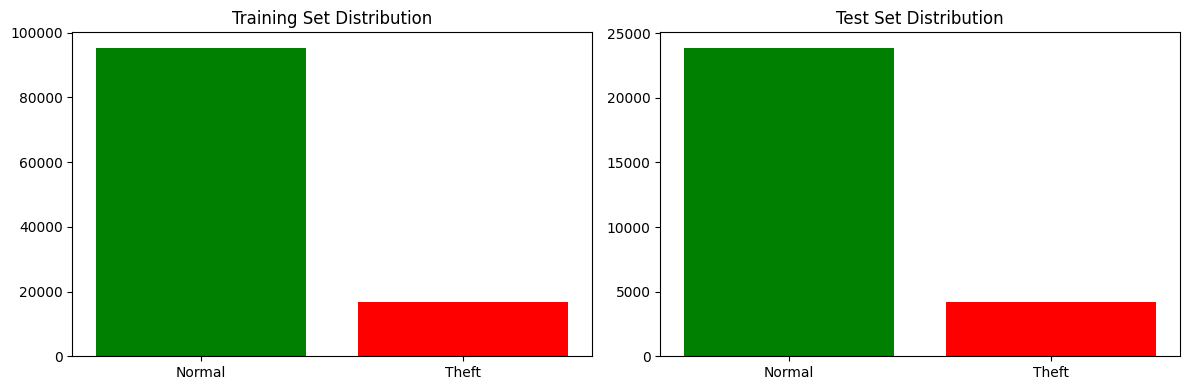

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

train_normal = int((y_train == 0).sum())
train_theft = int((y_train == 1).sum())
val_normal = int((y_val == 0).sum())
val_theft = int((y_val == 1).sum())
test_normal = int((y_test == 0).sum())
test_theft = int((y_test == 1).sum())

axes[0].bar(['Normal', 'Theft'], [train_normal, train_theft], color=['green', 'red'])
axes[0].set_title('Training Set')

axes[1].bar(['Normal', 'Theft'], [val_normal, val_theft], color=['green', 'red'])
axes[1].set_title('Validation Set')

axes[2].bar(['Normal', 'Theft'], [test_normal, test_theft], color=['green', 'red'])
axes[2].set_title('Test Set')

for ax in axes:
    ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Model Development

In this section, we define a Hybrid CNN-LSTM architecture. The CNN layers act as a feature extractor for local temporal patterns, while the bidirectional LSTM captures long-term dependencies in the electricity load sequences.

# Model Development

In this section, we define a Hybrid CNN-LSTM architecture. The CNN layers act as a feature extractor for local temporal patterns, while the bidirectional LSTM captures long-term dependencies in the electricity load sequences.

In [ ]:
class TheftDetectionLSTM(nn.Module):
    def __init__(self, i_sz=FEATURE_DIM, c=64, h=128, nl=2, d=0.3):
        super().__init__()
        self.f = nn.Sequential(nn.Conv1d(i_sz, c, 3, padding=1), nn.BatchNorm1d(c), nn.GELU(), nn.Dropout(d), nn.Conv1d(c, c, 3, padding=1), nn.BatchNorm1d(c), nn.GELU())
        self.lstm = nn.LSTM(c, h, nl, batch_first=True, bidirectional=True, dropout=d if nl>1 else 0)
        self.c = nn.Sequential(nn.LayerNorm(h*2), nn.Linear(h*2, 64), nn.GELU(), nn.Dropout(d), nn.Linear(64, 1))

    def forward(self, x):
        _, (hn, _) = self.lstm(self.f(x.transpose(1, 2)).transpose(1, 2))
        return self.c(torch.cat([hn[-2], hn[-1]], -1)).squeeze(-1)

model = TheftDetectionLSTM().to(device)
print(f'Model loaded. Total parameters: {sum(p.numel() for p in model.parameters())}')

TheftDetectionLSTM(
  (feature_extractor): Sequential(
    (0): Conv1d(14, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.3, inplace=False)
    (4): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
  )
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (classifier): Sequential(
    (0): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=256, out_features=64, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)
Total parameters: 626305


# Training and Optimization

We utilize **Focal Loss** to address the class imbalance (10% anomalies). The training process includes:
* **Mixed Precision (AMP)** for faster computation on GPUs.
* **ReduceLROnPlateau** scheduler to tune the learning rate based on Validation F1.
* **Early Stopping** to prevent overfitting.

# Training and Optimization

We utilize **Focal Loss** to address the class imbalance (10% anomalies). The training process includes:
* **Mixed Precision (AMP)** for faster computation on GPUs.
* **ReduceLROnPlateau** scheduler to tune the learning rate based on Validation F1.
* **Early Stopping** to prevent overfitting.

Epoch [01/100] train_loss=0.0477 val_loss=0.0435 val_ap=0.6947 val_f1=0.6848 val_precision=0.9211 val_recall=0.5450 threshold=0.69
Epoch [02/100] train_loss=0.0448 val_loss=0.0462 val_ap=0.7193 val_f1=0.7125 val_precision=0.9150 val_recall=0.5833 threshold=0.69
Epoch [03/100] train_loss=0.0443 val_loss=0.0453 val_ap=0.7172 val_f1=0.7008 val_precision=0.8558 val_recall=0.5933 threshold=0.67
Epoch [04/100] train_loss=0.0432 val_loss=0.0445 val_ap=0.7446 val_f1=0.7398 val_precision=0.9283 val_recall=0.6150 threshold=0.76
Epoch [05/100] train_loss=0.0430 val_loss=0.0419 val_ap=0.7054 val_f1=0.6907 val_precision=0.8627 val_recall=0.5758 threshold=0.63
Epoch [06/100] train_loss=0.0423 val_loss=0.0415 val_ap=0.7513 val_f1=0.7479 val_precision=0.9384 val_recall=0.6217 threshold=0.69
Epoch [07/100] train_loss=0.0421 val_loss=0.0407 val_ap=0.7235 val_f1=0.7171 val_precision=0.8911 val_recall=0.6000 threshold=0.64
Epoch [08/100] train_loss=0.0420 val_loss=0.0439 val_ap=0.7233 val_f1=0.7258 val_pr

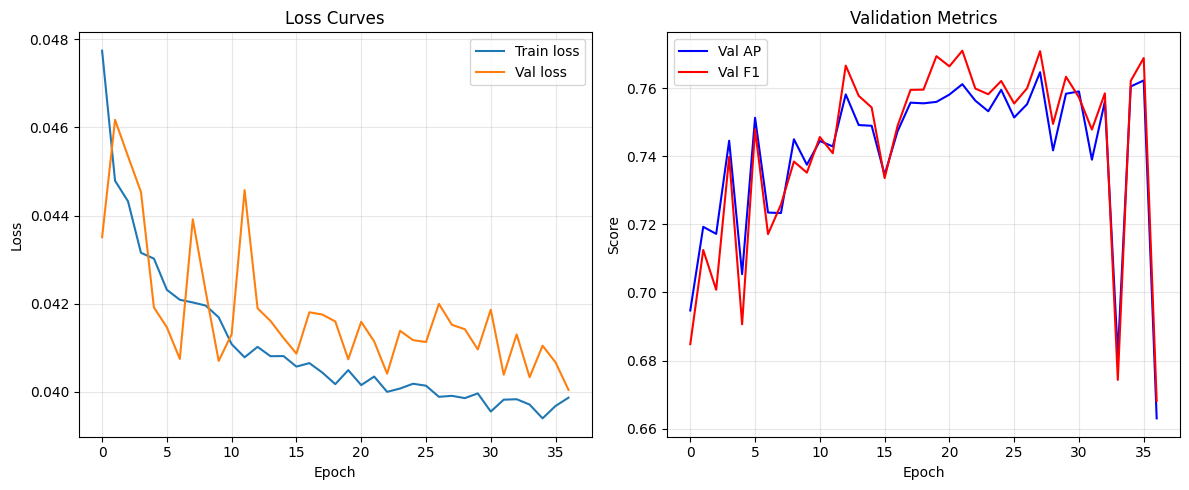

Best validation F1: 0.7710 at threshold 0.75
Best validation AP: 0.7612
Model saved to theft_detection_lstm.pth after 37 epochs.


In [ ]:
from copy import deepcopy
class FocalLoss(nn.Module):
    def forward(self, l, t):
        p = torch.sigmoid(l); pt = torch.where(t==1.0, p, 1.0-p)
        return (torch.where(t==1.0, 0.8, 0.2).to(l.device) * torch.pow(1.0-pt, 2.0) * F.binary_cross_entropy_with_logits(l, t, reduction='none')).mean()

criterion, optimizer = FocalLoss(), torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler, scaler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', 0.5, patience=3, min_lr=1e-5), torch.cuda.amp.GradScaler(enabled=USE_AMP)

best_clean_state, best_f1, best_threshold, best_val_ap, p_cnt, best_threshold_metrics = None, -np.inf, 0.5, -np.inf, 0, {}

def collect_probabilities(loader):
    model.eval(); lg, pr, tg, ls, c = [], [], [], 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device, non_blocking=PIN_MEMORY), y.float().to(device, non_blocking=PIN_MEMORY)
            with torch.autocast('cuda' if USE_GPU else 'cpu', enabled=USE_AMP): l = model(X); ls += criterion(l, y).item() * len(y)
            lg.append(l.cpu().numpy()); pr.append(torch.sigmoid(l).cpu().numpy()); tg.append(y.cpu().numpy()); c += len(y)
    return np.concatenate(lg), np.concatenate(pr), np.concatenate(tg), ls/max(c,1)

for ep in range(100):
    model.train(); ls, c = 0, 0
    for X, y in train_loader:
        X, y = X.to(device, non_blocking=PIN_MEMORY), y.float().to(device, non_blocking=PIN_MEMORY)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast('cuda' if USE_GPU else 'cpu', enabled=USE_AMP): loss = criterion(model(X), y)
        scaler.scale(loss).backward(); scaler.unscale_(optimizer); nn.utils.clip_grad_norm_(model.parameters(), 1.0); scaler.step(optimizer); scaler.update(); ls += loss.item(); c += 1

    vl, vp, vt, vls = collect_probabilities(val_loader)
    ths = np.linspace(0.05, 0.95, 91)
    ms = [(t, metrics.f1_score(vt, vp>=t, zero_division=0), metrics.precision_score(vt, vp>=t, zero_division=0), metrics.recall_score(vt, vp>=t, zero_division=0)) for t in ths]
    th, f1, prec, rec = max(ms, key=lambda x: x[1])
    ap = metrics.average_precision_score(vt, vp) if len(np.unique(vt))>1 else 0
    scheduler.step(f1)
    print(f"Ep {ep+1:02d} | T-Loss: {ls/c:.4f} | V-Loss: {vls:.4f} | AP: {ap:.4f} | F1: {f1:.4f} | Th: {th:.2f}")

    if f1 > best_f1 + 1e-4:
        best_f1, best_val_ap, best_threshold, best_clean_state, p_cnt = f1, ap, th, deepcopy(model.state_dict()), 0
        best_threshold_metrics = {'threshold': th, 'f1': f1, 'precision': prec, 'recall': rec, 'balanced_accuracy': metrics.balanced_accuracy_score(vt, vp>=th), 'mcc': metrics.matthews_corrcoef(vt, vp>=th)}
    elif (p_cnt := p_cnt + 1) >= 15: break

model.load_state_dict(best_clean_state)

# Model Evaluation

We evaluate the model using the best weights saved during training. Metrics include F1-Score, PR-AUC, and ROC-AUC to provide a comprehensive view of detection performance.

# Model Evaluation

We evaluate the model using the best weights saved during training. Metrics include F1-Score, PR-AUC, and ROC-AUC to provide a comprehensive view of detection performance.

In [ ]:
model.load_state_dict(best_clean_state); model.eval()
all_logits, all_probs, y_true, test_loss = collect_probabilities(test_loader)
all_preds = (all_probs >= best_threshold).astype(np.int64)

prc, rec, f1, _ = metrics.precision_recall_fscore_support(y_true, all_preds, average='binary', zero_division=0)
prec_c, rec_c, _ = metrics.precision_recall_curve(y_true, all_probs)
pr_auc, roc_auc = metrics.auc(rec_c, prec_c), metrics.roc_auc_score(y_true, all_probs)
cm = metrics.confusion_matrix(y_true, all_preds)

test_metrics = { 'precision': float(prc), 'recall': float(rec), 'f1': float(f1), 'balanced_accuracy': float(metrics.balanced_accuracy_score(y_true, all_preds)), 'mcc': float(metrics.matthews_corrcoef(y_true, all_preds)), 'cohen_kappa': float(metrics.cohen_kappa_score(y_true, all_preds)), 'test_loss': float(test_loss), 'threshold': float(best_threshold), 'brier': float(metrics.brier_score_loss(y_true, all_probs)), 'logloss': float(metrics.log_loss(y_true, np.clip(all_probs, 1e-6, 1-1e-6))), 'pr_auc': float(pr_auc), 'roc_auc': float(roc_auc) }

print(f"Test F1: {f1:.4f} | PR-AUC: {pr_auc:.4f} | ROC-AUC: {roc_auc:.4f}")

Validation-selected threshold: 0.75
Best validation metrics: {'threshold': 0.7499999999999999, 'precision': 0.9544895448954489, 'recall': 0.6466666666666666, 'f1': 0.7709885742672627, 'balanced_accuracy': 0.8216205289633676, 'mcc': 0.7678473008273503}
Test Precision: 0.9422
Test Recall:    0.6112
Test F1-Score:  0.7415
Test Balanced Accuracy: 0.8035
Test MCC: 0.7394
Test Cohen Kappa: 0.7194
Test PR-AUC: 0.7443
Test ROC-AUC: 0.8718
Test Brier Score: 0.2476
Test Log Loss: 0.6786

Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      1.00      0.98     21600
       Theft       0.94      0.61      0.74      2400

    accuracy                           0.96     24000
   macro avg       0.95      0.80      0.86     24000
weighted avg       0.96      0.96      0.95     24000



## Explainability Analysis (SHAP)

After baseline evaluation, this section inspects which time steps and cyclical features influence model decisions.

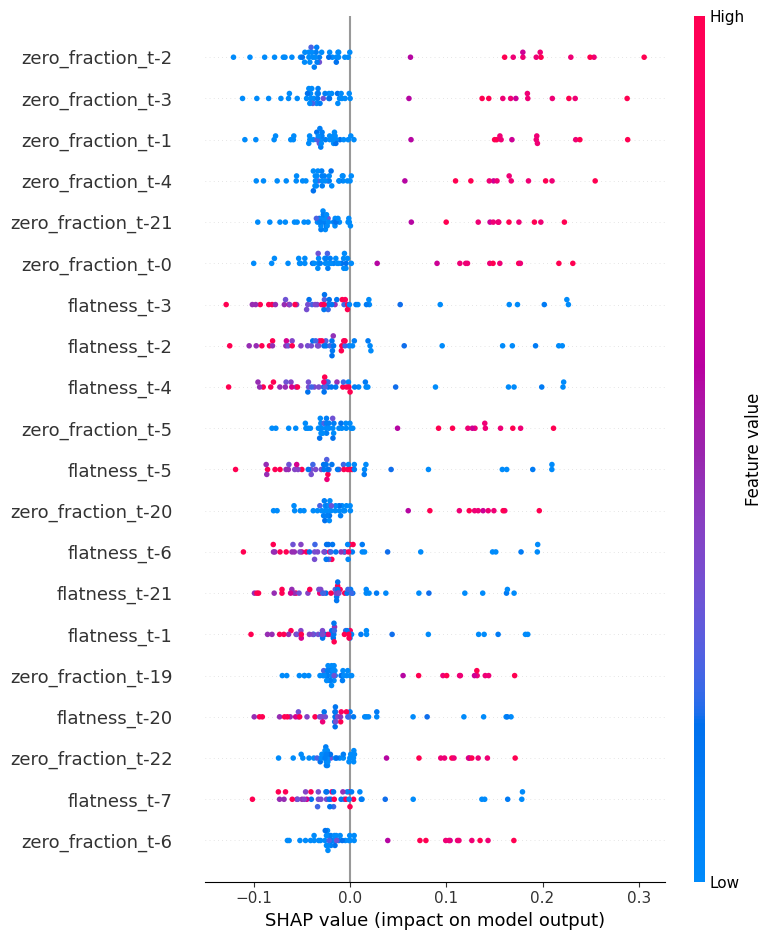

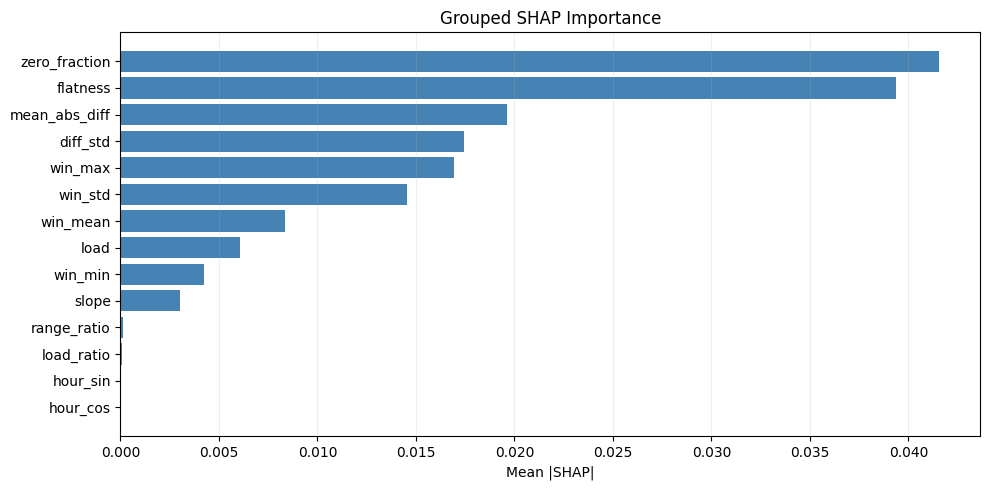

SHAP computed on NVIDIA GeForce RTX 3090 with background=96, test_samples=48, nsamples=32
Top 10 features by mean |SHAP|:
 1. zero_fraction_t-2: 0.07970
 2. zero_fraction_t-3: 0.07283
 3. zero_fraction_t-1: 0.07134
 4. zero_fraction_t-4: 0.06487
 5. zero_fraction_t-21: 0.06209
 6. zero_fraction_t-0: 0.05900
 7. flatness_t-3: 0.05785
 8. flatness_t-2: 0.05684
 9. flatness_t-4: 0.05639
10. zero_fraction_t-5: 0.05475
Top feature groups by mean |SHAP|:
 1. zero_fraction: 0.04156
 2. flatness: 0.03937
 3. mean_abs_diff: 0.01960
 4. diff_std: 0.01746
 5. win_max: 0.01694
 6. win_std: 0.01454
 7. win_mean: 0.00837
 8. load: 0.00604
 9. win_min: 0.00424
10. slope: 0.00302


In [ ]:
model.eval()
class SHAPWrapper(nn.Module):
    def __init__(self, m): super().__init__(); self.m = m
    def forward(self, x): return self.m(x).unsqueeze(-1)

def balanced_idx(y, k, s=SEED):
    rng = np.random.default_rng(s)
    p, n = np.where(y==1)[0], np.where(y==0)[0]
    return np.concatenate([rng.choice(n, min(len(n), k-min(len(p), k//2)), False), rng.choice(p, min(len(p), k//2), False)])

shap_dev = device if USE_GPU else torch.device('cpu')
shap_model = SHAPWrapper(model).to(shap_dev).eval()

te_idx = balanced_idx(y_test, 48)
bg, te = X_train_t[balanced_idx(y_train, 96)].to(shap_dev), X_test_t[te_idx].to(shap_dev)
sub_y, sub_p, sub_pr = y_test[te_idx], all_preds[te_idx], all_probs[te_idx]

cudnn = torch.backends.cudnn.enabled
torch.backends.cudnn.enabled = False
sv = np.asarray(shap.GradientExplainer(shap_model, bg).shap_values(te, nsamples=32))
torch.backends.cudnn.enabled = cudnn

sv = sv[..., 0] if sv.ndim == 4 else sv
sv_flat, te_flat = sv.reshape(sv.shape[0], -1), te.cpu().numpy().reshape(te.shape[0], -1)
f_names = [f'{n}_t-{WINDOW_SIZE-1-s}' for s in range(WINDOW_SIZE) for n in FEATURE_NAMES]

mas = np.mean(np.abs(sv_flat), axis=0)
fg_imp = {n: float(np.mean(np.abs(sv_flat[:, i::FEATURE_DIM]))) for i, n in enumerate(FEATURE_NAMES)}

plt.figure(figsize=(10, 4))
shap.summary_plot(sv_flat, te_flat, feature_names=f_names, max_display=15, show=False)
plt.show()

### Local Explanations (SHAP)
Examines individual predictions (True Positives, False Positives, etc.) to see which specific features and time steps drove the model's decision for a particular window.

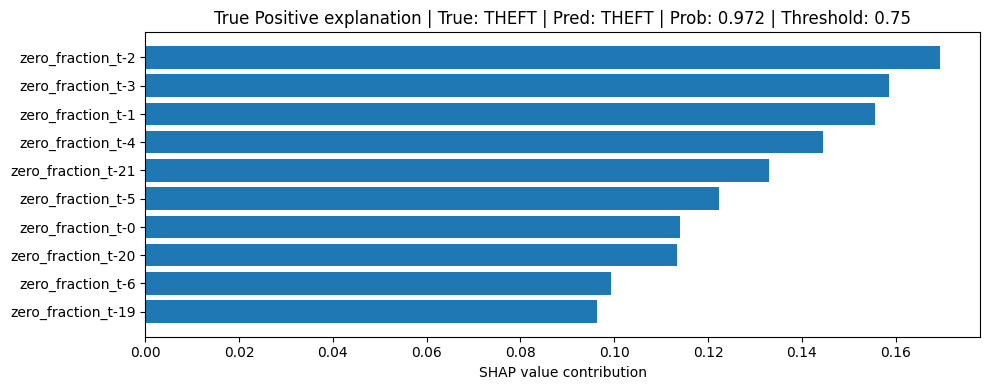

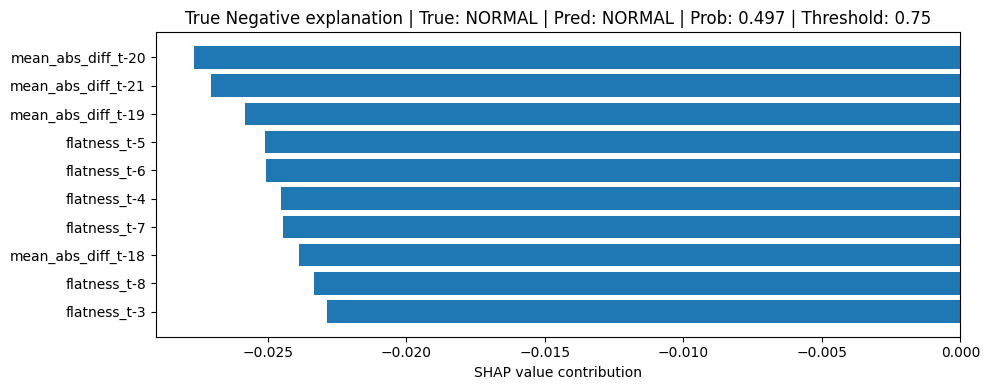

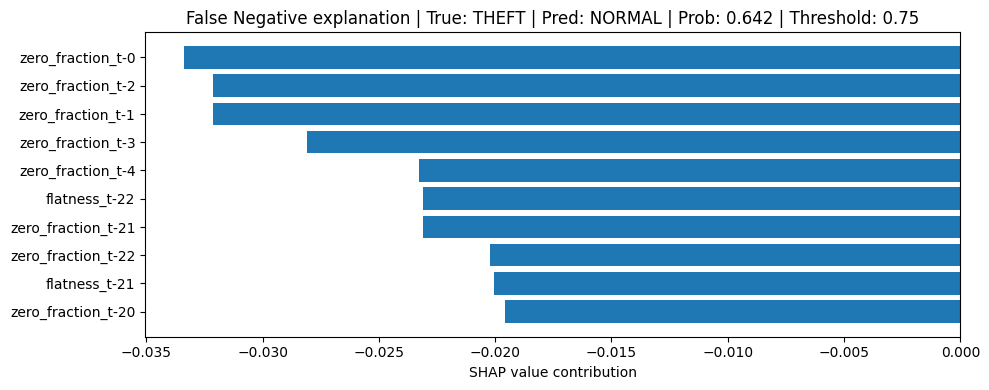

In [ ]:
candidates = [('TP', (sub_y==1)&(sub_p==1)), ('TN', (sub_y==0)&(sub_p==0)), ('FP', (sub_y==0)&(sub_p==1)), ('FN', (sub_y==1)&(sub_p==0))]
for lbl, mask in [x for x in candidates if x[1].sum() > 0][:4]:
    idx = np.where(mask)[0][0]; ss = sv_flat[idx]; top = np.argsort(np.abs(ss))[-10:]
    plt.figure(figsize=(8,3)); plt.barh([f_names[i] for i in top], ss[top])
    plt.title(f"{lbl} | True: {sub_y[idx]} | Pred: {sub_p[idx]} | Prob: {sub_pr[idx]:.3f}"); plt.show()

## Adversarial Robustness Testing (FGSM)

This section measures how performance changes under bounded perturbations and visualizes robustness trends across epsilon levels.

### FGSM Attack Definition
Implements the Fast Gradient Sign Method (FGSM) to generate adversarial perturbations bounded by a specific $\epsilon$.

In [ ]:
attack_criterion, x_min, x_max = nn.BCEWithLogitsLoss(), float(X_train_t.min()), float(X_train_t.max())
def fgsm_attack(m, x, y, eps=0.05):
    x_adv = x.clone().detach().to(device).requires_grad_(True)
    with torch.enable_grad(), torch.backends.cudnn.flags(enabled=False):
        grad = torch.autograd.grad(attack_criterion(m(x_adv), y.float().to(device)), x_adv)[0]
    return torch.clamp(x_adv + eps * grad.sign(), x_min, x_max).detach()

### Adversarial Evaluation
Evaluates the model's performance degradation (F1 Score, Precision, Recall) as the attack strength ($\epsilon$) increases.

In [ ]:
robustness_results, y_true = {}, y_test_t.numpy()
for eps in [0.0, 0.01, 0.05, 0.1]:
    model.eval(); aprobs = []
    for i in range(0, len(X_test_t), EVAL_BATCH_SIZE):
        bx, by = X_test_t[i:i+EVAL_BATCH_SIZE].to(device), y_test_t[i:i+EVAL_BATCH_SIZE].to(device)
        with torch.no_grad(): aprobs.extend(torch.sigmoid(model(fgsm_attack(model, bx, by, eps) if eps > 0 else bx)).cpu().numpy())
    apreds, aprobs = (np.asarray(aprobs) >= best_threshold).astype(int), np.asarray(aprobs)
    fn, tp = ((y_true==1)&(apreds==0)).sum(), ((y_true==1)&(apreds==1)).sum()
    robustness_results[eps] = {'precision': float(metrics.precision_score(y_true, apreds, zero_division=0)), 'recall': float(metrics.recall_score(y_true, apreds, zero_division=0)), 'f1': float(metrics.f1_score(y_true, apreds, zero_division=0)), 'balanced_accuracy': float(metrics.balanced_accuracy_score(y_true, apreds)), 'mcc': float(metrics.matthews_corrcoef(y_true, apreds)), 'fnr': float(fn/max(fn+tp,1)), 'ap': float(metrics.average_precision_score(y_true, aprobs) if len(np.unique(y_true))>1 else 0)}
    print(f"Eps {eps:.2f} | F1: {robustness_results[eps]['f1']:.4f} | AP: {robustness_results[eps]['ap']:.4f}")


Adversarial Robustness Results:
Epsilon    Precision    Recall       F1-Score     BAcc         FNR        AP          
------------------------------------------------------------------------------------
0.00       0.9428       0.6108       0.7413       0.8034       0.3892     0.7443      
0.01       0.7139       0.5417       0.6160       0.7588       0.4583     0.6425      
0.05       0.2289       0.3150       0.2651       0.5985       0.6850     0.2780      
0.10       0.1656       0.3013       0.2137       0.5663       0.6987     0.1880      


# Results Visualization

Finally, we visualize the model's performance through the Precision-Recall curve and a Confusion Matrix to understand the trade-off between False Positives and False Negatives.

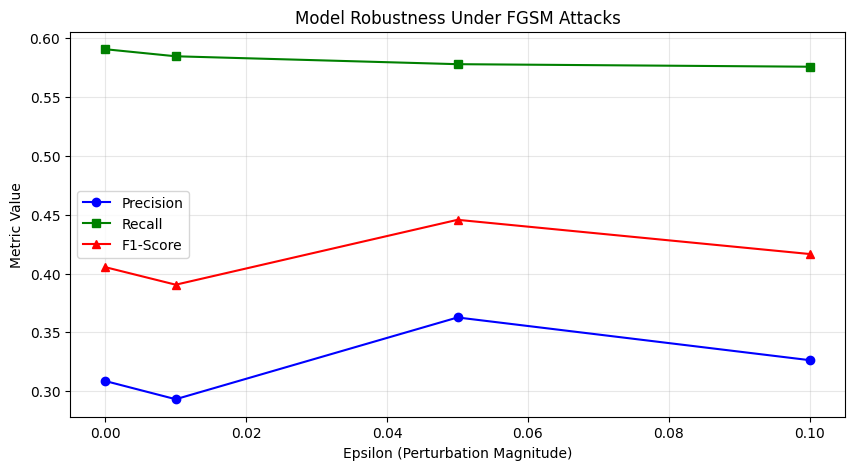

In [ ]:
eps = list(robustness_results.keys())
plt.figure(figsize=(10, 4))
for k, m, c in [('precision', 'o-', 'blue'), ('recall', 's-', 'green'), ('f1', '^-', 'red')]:
    plt.plot(eps, [robustness_results[e][k] for e in eps], m, label=k.title(), color=c)
plt.xlabel('Epsilon'); plt.ylabel('Metric'); plt.title('Robustness Under FGSM'); plt.legend(); plt.grid(alpha=0.3)
plt.savefig('adversarial_robustness.png', dpi=150, bbox_inches='tight'); plt.show()

### Confusion Matrix & Precision-Recall
Analyzes the detailed classification metrics to evaluate the trade-off between false positives and false negatives.

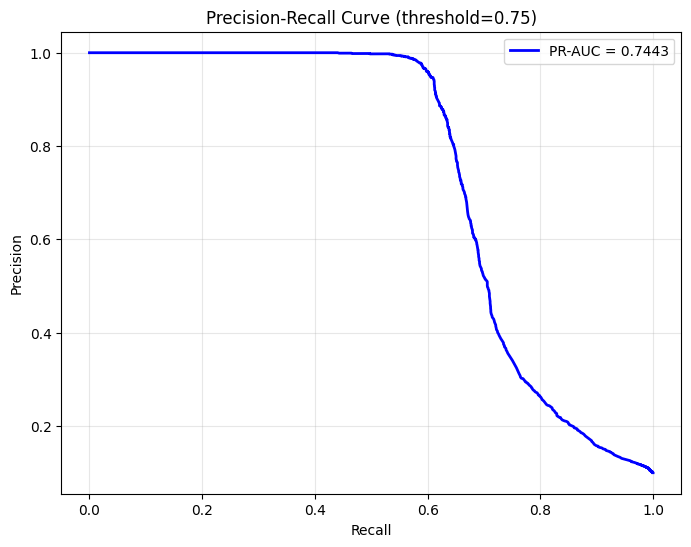

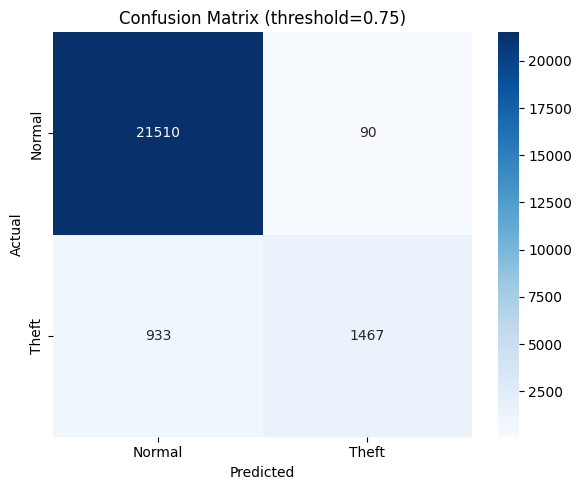

Confusion Matrix:
[[21510    90]
 [  933  1467]]


In [ ]:
pc, rc, _ = metrics.precision_recall_curve(y_true, all_probs)
plt.figure(figsize=(8, 4)); plt.plot(rc, pc, label=f'PR-AUC = {metrics.auc(rc, pc):.4f}', lw=2)
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title(f'PR Curve (th={best_threshold:.2f})'); plt.legend(); plt.grid(alpha=0.3)
plt.savefig('pr_curve.png', dpi=150, bbox_inches='tight'); plt.show()

plt.figure(figsize=(5, 4)); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Theft'], yticklabels=['Normal', 'Theft'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title(f'Confusion Matrix (th={best_threshold:.2f})')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight'); plt.show()

### ROC Curve
Visualizes the Receiver Operating Characteristic curve to assess the overall discriminative ability of the model across different thresholds.

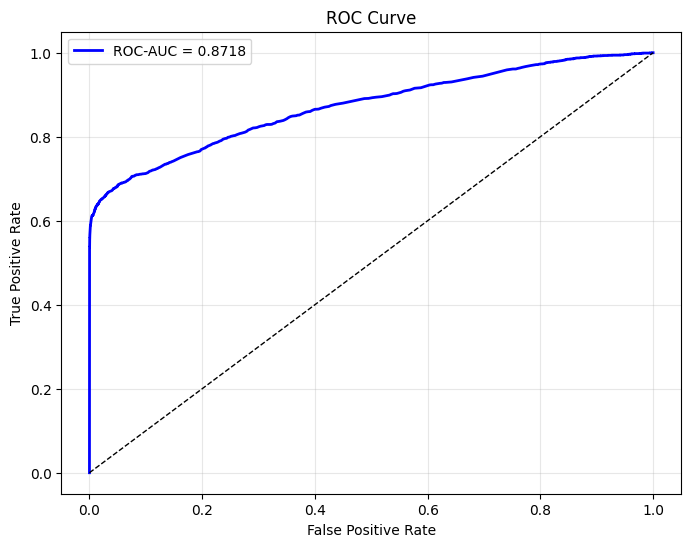

In [ ]:
fpr, tpr, _ = metrics.roc_curve(y_true, all_probs)
plt.figure(figsize=(8, 4)); plt.plot(fpr, tpr, label=f'ROC-AUC = {metrics.auc(fpr, tpr):.4f}', lw=2); plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curve'); plt.legend(); plt.grid(alpha=0.3)
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight'); plt.show()

### Text Summary & Export
Prints a consolidated summary of validation, test, and robustness metrics, and exports all results to a structured JSON file.

In [ ]:
print(f"""{'='*60}\nFINAL RESULTS SUMMARY\n{'='*60}
1. Val Rule: Th={best_threshold:.2f} | F1={best_threshold_metrics.get('f1',0):.4f} | Prec={best_threshold_metrics.get('precision',0):.4f}
2. Test Perf: Prec={test_metrics['precision']:.4f} | Rec={test_metrics['recall']:.4f} | F1={test_metrics['f1']:.4f} | BAcc={test_metrics['balanced_accuracy']:.4f}
3. Robustness (FGSM):""")
for e, m in robustness_results.items(): print(f"   Eps={e:.2f} | F1={m['f1']:.4f} | Prec={m['precision']:.4f} | Rec={m['recall']:.4f}")

FINAL RESULTS SUMMARY

1. Validation-Selected Decision Rule:
   Best threshold: 0.75
   Best validation F1: 0.7710
   Best validation precision: 0.9545
   Best validation recall: 0.6467

2. Test Performance:
   Precision: 0.9422
   Recall:    0.6112
   F1-Score:  0.7415
   Balanced Accuracy: 0.8035
   MCC:      0.7394
   PR-AUC:   0.7443
   ROC-AUC:  0.8718

3. Robustness Under FGSM:
   Epsilon=0.00: F1=0.7413, Precision=0.9428, Recall=0.6108, F1-Drop=0.0000
   Epsilon=0.01: F1=0.6160, Precision=0.7139, Recall=0.5417, F1-Drop=0.1254
   Epsilon=0.05: F1=0.2651, Precision=0.2289, Recall=0.3150, F1-Drop=0.4762
   Epsilon=0.10: F1=0.2137, Precision=0.1656, Recall=0.3013, F1-Drop=0.5276

4. Explainability Outputs:
   SHAP summary: shap_summary.png
   SHAP grouped importance: shap_group_importance.png
   Local SHAP plots: shap_local_bar_*.png


In [ ]:
import json
def jsonable(v): return v.item() if isinstance(v, (np.floating, np.integer)) else v
results = {
    'best_threshold': float(best_threshold),
    'validation_metrics': {k: jsonable(v) for k, v in best_threshold_metrics.items()},
    'test_metrics': {k: jsonable(v) for k, v in test_metrics.items()},
    'robustness_under_attack': {str(e): {k: jsonable(v) for k, v in m.items()} for e, m in robustness_results.items()},
    'feature_group_importance': fg_imp, 'confusion_matrix': cm.tolist(),
    'pr_auc': float(pr_auc), 'roc_auc': float(roc_auc),
    'brier_score': float(test_metrics['brier']), 'log_loss': float(test_metrics['logloss'])
}
with open('results.json', 'w') as f: json.dump(results, f, indent=2)
print('Results exported to results.json')

{
  "best_threshold": 0.7499999999999999,
  "validation_metrics": {
    "threshold": 0.7499999999999999,
    "precision": 0.9544895448954489,
    "recall": 0.6466666666666666,
    "f1": 0.7709885742672627,
    "balanced_accuracy": 0.8216205289633676,
    "mcc": 0.7678473008273503
  },
  "test_metrics": {
    "precision": 0.9421965317919075,
    "recall": 0.61125,
    "f1": 0.7414708112206216,
    "balanced_accuracy": 0.8035416666666666,
    "mcc": 0.7394282612625832,
    "cohen_kappa": 0.7193877551020409,
    "test_loss": 0.04110144074757894,
    "threshold": 0.7499999999999999,
    "brier": 0.24755802750587463,
    "logloss": 0.678635684329065,
    "pr_auc": 0.7443046119168805,
    "roc_auc": 0.8718097993827161
  },
  "robustness_under_attack": {
    "0.0": {
      "precision": 0.9427652733118971,
      "recall": 0.6108333333333333,
      "f1": 0.7413400758533502,
      "balanced_accuracy": 0.8033564814814815,
      "mcc": 0.7394192776325024,
      "fnr": 0.38916666666666666,
      "a